In [18]:
import pandas as pd

#1. Cargar el archivo CSV en un DataFrame
df_customers = pd.read_csv('customer_data_2023.csv')
df_sales = pd.read_csv('sales_data_2023.csv')

#2. Mostrar las primeras filas de cada DataFrame para identificar las columnas y los tipos de datos
print("DATOS DEL CLIENTE ------------")
print(df_customers.head())

print("\nDATOS DE VENTAS------------")
print(df_sales.head())

DATOS DEL CLIENTE ------------
   Customer_ID Customer_Name  Customer_Age Geography
0            1    Customer_1            20      West
1            2    Customer_2            69     North
2            3    Customer_3            57      West
3            4    Customer_4            66      East
4            5    Customer_5            59     South

DATOS DE VENTAS------------
   Sale_ID  Customer_ID  Sale_Amount   Sale_Date Geography
0        1           38        31.11  2023-05-03      West
1        2           18       191.54  2023-03-06     South
2        3          197       283.74  2023-06-23      East
3        4          185       367.13  2023-02-09     South
4        5          171       188.52  2023-12-25     South


In [19]:


print("Datos totales de clientes: ", df_customers.shape)
print("Datos totales de ventas: ", df_sales.shape)

Datos totales de clientes:  (300, 4)
Datos totales de ventas:  (1000, 5)


In [20]:
print("\nTIPOS DE DATOS DEL CLIENTE------------")
print(df_customers.info())    

print("\nTIPOS DE DATOS DE VENTAS------------")
print(df_sales.info()) 


TIPOS DE DATOS DEL CLIENTE------------
<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   Customer_ID    300 non-null    int64
 1   Customer_Name  300 non-null    str  
 2   Customer_Age   300 non-null    int64
 3   Geography      300 non-null    str  
dtypes: int64(2), str(2)
memory usage: 9.5 KB
None

TIPOS DE DATOS DE VENTAS------------
<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sale_ID      1000 non-null   int64  
 1   Customer_ID  1000 non-null   int64  
 2   Sale_Amount  1000 non-null   float64
 3   Sale_Date    1000 non-null   str    
 4   Geography    1000 non-null   str    
dtypes: float64(1), int64(2), str(2)
memory usage: 39.2 KB
None


In [22]:
# 3. Convertir la columna Sale_Date a tipo datetime
df_sales['Sale_Date'] = pd.to_datetime(df_sales['Sale_Date'])

print(f"Tipo de dato de Sale_Date ahora: {df_sales['Sale_Date'].dtype}")
print(df_sales.dtypes)

Tipo de dato de Sale_Date ahora: datetime64[us]
Sale_ID                 int64
Customer_ID             int64
Sale_Amount           float64
Sale_Date      datetime64[us]
Geography                 str
dtype: object


In [15]:
# 4. Verificar si hay registros completamente duplicados
duplicados_clientes = df_customers.duplicated().sum()
duplicados_ventas = df_sales.duplicated().sum()

print("--- REVISIÓN DE CAMBIOS Y DUPLICADOS ---")
print(f"Registros duplicados en Clientes: {duplicados_clientes}")
print(f"Registros duplicados en Ventas: {duplicados_ventas}")

--- REVISIÓN DE CAMBIOS Y DUPLICADOS ---
Registros duplicados en Clientes: 0
Registros duplicados en Ventas: 0


In [16]:
print("--- VALORES FALTANTES EN CLIENTES ---")
print(df_customers.isnull().sum())

print("\n--- VALORES FALTANTES EN VENTAS ---")
print(df_sales.isnull().sum())

--- VALORES FALTANTES EN CLIENTES ---
Customer_ID      0
Customer_Name    0
Customer_Age     0
Geography        0
dtype: int64

--- VALORES FALTANTES EN VENTAS ---
Sale_ID        0
Customer_ID    0
Sale_Amount    0
Sale_Date      0
Geography      0
dtype: int64


## VALORES ATIPICOS

In [10]:
# Definimos una función para encontrar los límites usando el método IQR
def detectar_limites_outliers(df, columna):
    Q1 = df[columna].quantile(0.25) # Primer cuartil (25%)
    Q3 = df[columna].quantile(0.75) # Tercer cuartil (75%)
    IQR = Q3 - Q1                  # Rango Intercuartílico
    
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    
    return limite_inferior, limite_superior

In [9]:
lim_inf_edad, lim_sup_edad = detectar_limites_outliers(df_customers, 'Customer_Age')
lim_inf_ventas, lim_sup_ventas = detectar_limites_outliers(df_sales, 'Sale_Amount')

print("\n--- DETECCIÓN DE OUTLIERS EN VENTAS ---")
# Aplicamos la función a la columna 'Sale_Amount'
print(f"Límite inferior: {lim_inf_ventas}, Límite superior: {lim_sup_ventas}")

print("\n--- DETECCIÓN DE OUTLIERS EN CLIENTES ---")
# Aplicamos la función a la columna 'Customer_Age'
print(f"Límite inferior: {lim_inf_edad}, Límite superior: {lim_sup_edad}")


--- DETECCIÓN DE OUTLIERS EN VENTAS ---
Límite inferior: -248.95124999999996, Límite superior: 746.37875

--- DETECCIÓN DE OUTLIERS EN CLIENTES ---
Límite inferior: -6.0, Límite superior: 90.0


In [11]:
# 1. Obtener los límites para la columna Sale_Amount
lim_inf_ventas, lim_sup_ventas = detectar_limites_outliers(df_sales, 'Sale_Amount')

# 2. Filtrar las filas completas que estén fuera de los límites
outliers_totales_sales = df_sales[
    (df_sales['Sale_Amount'] < lim_inf_ventas) | 
    (df_sales['Sale_Amount'] > lim_sup_ventas)
]

# 3. Mostrar cuántas filas tienen outliers en total
print(f"Número total de filas con outliers en Ventas: {len(outliers_totales_sales)}")

Número total de filas con outliers en Ventas: 0


In [12]:
# 1. Obtener los límites para la columna Customer_Age
lim_inf_edad, lim_sup_edad = detectar_limites_outliers(df_customers, 'Customer_Age')

# 2. Filtrar las filas completas que estén fuera de los límites
outliers_totales_clientes = df_customers[
    (df_customers['Customer_Age'] < lim_inf_edad) | 
    (df_customers['Customer_Age'] > lim_sup_edad)
]

# 3. Mostrar cuántas filas tienen outliers en total
print(f"Número total de filas con outliers en Clientes: {len(outliers_totales_clientes)}")

Número total de filas con outliers en Clientes: 0


In [13]:
# 2. NUEVA FUNCIÓN: Extrae y devuelve la sub-tabla de outliers
def obtener_tabla_outliers(df, columna):
    # Invocamos la función anterior para obtener los límites de esta columna específica
    lim_inf, lim_sup = detectar_limites_outliers(df, columna)
    
    # Aplicamos la indexación booleana usando los límites calculados
    df_outliers = df[(df[columna] < lim_inf) | (df[columna] > lim_sup)]
    
    # Devolvemos el DataFrame resultante listo para usarse
    return df_outliers

In [14]:
# Mapeo directo para Clientes
outliers_clientes = obtener_tabla_outliers(df_customers, 'Customer_Age')
print(f"Número total de filas con outliers en Clientes: {len(outliers_clientes)}")

# Mapeo directo para Ventas
outliers_ventas = obtener_tabla_outliers(df_sales, 'Sale_Amount')
print(f"Número total de filas con outliers en Ventas: {len(outliers_ventas)}")

Número total de filas con outliers en Clientes: 0
Número total de filas con outliers en Ventas: 0


### AGRUPACION POR MES

In [23]:
# Creación de la columna de periodo mensual (Año-Mes)
df_sales['Sale_Month'] = df_sales['Sale_Date'].dt.to_period('M')

# Inspección rápida para verificar la nueva columna
print("--- VERIFICACIÓN DE LA COLUMNA MENSUAL ---")
display(df_sales[['Sale_Date', 'Sale_Month', 'Sale_Amount', 'Geography']].head())

--- VERIFICACIÓN DE LA COLUMNA MENSUAL ---


,Sale_Date,Sale_Month,Sale_Amount,Geography
0,2023-05-03,2023-05,31.11,West
1,2023-03-06,2023-03,191.54,South
2,2023-06-23,2023-06,283.74,East
3,2023-02-09,2023-02,367.13,South
4,2023-12-25,2023-12,188.52,South


In [24]:
# 1. Estandarizar con la primera letra en Mayúscula (.str.title()) y remover espacios vacíos (.str.strip())
df_sales['Geography'] = df_sales['Geography'].str.title().str.strip()
df_customers['Geography'] = df_customers['Geography'].str.title().str.strip()

# 2. Verificación de los valores únicos resultantes
print("--- REGIONES ESTANDARIZADAS EN VENTAS ---")
print(df_sales['Geography'].unique())

print("\n--- REGIONES ESTANDARIZADAS EN CLIENTES ---")
print(df_customers['Geography'].unique())

--- REGIONES ESTANDARIZADAS EN VENTAS ---
<StringArray>
['West', 'South', 'East', 'North']
Length: 4, dtype: str

--- REGIONES ESTANDARIZADAS EN CLIENTES ---
<StringArray>
['West', 'North', 'East', 'South']
Length: 4, dtype: str


In [27]:
# 1. Agrupar las ventas consolidando el total (suma) por Mes y por Región Geográfica
ventas_mensuales_region = df_sales.groupby(['Geography', 'Sale_Month'])['Sale_Amount'].sum().reset_index()

# 2. Visualizar las primeras filas de la tabla resumen resultante
print("--- TABLA RESUMEN DE TENDENCIAS MENSUALES POR REGIÓN ---")
display(ventas_mensuales_region)

--- TABLA RESUMEN DE TENDENCIAS MENSUALES POR REGIÓN ---


,Geography,Sale_Month,Sale_Amount
0,East,2023-01,4233.80
1,East,2023-02,7086.44
2,East,2023-03,5520.28
3,East,2023-04,3018.57
4,East,2023-05,5016.02
5,East,2023-06,5006.57
6,East,2023-07,4775.51
7,East,2023-08,5365.54
8,East,2023-09,5437.34
9,East,2023-10,5254.31


# CREACION DE GRAFICAS

In [28]:
# 1. Convertir el periodo a texto para evitar problemas al graficar
ventas_mensuales_region['Sale_Month'] = ventas_mensuales_region['Sale_Month'].astype(str)

# 2. Pivotar la tabla: Mes en las filas, Regiones en las columnas y Ventas en las celdas
tabla_pivote = ventas_mensuales_region.pivot(index='Sale_Month', columns='Geography', values='Sale_Amount')

# 3. Mostrar cómo quedó la estructura
print("--- TABLA OPTIMIZADA PARA GRAFICAR ---")
display(tabla_pivote.head())

--- TABLA OPTIMIZADA PARA GRAFICAR ---


Geography,East,North,South,West
Sale_Month,,,,
2023-01,4233.80,6436.71,5950.96,3584.70
2023-02,7086.44,4812.83,6324.87,5146.71
2023-03,5520.28,7153.31,6378.26,7600.63
2023-04,3018.57,3776.72,4056.91,6197.00
2023-05,5016.02,7621.22,4605.35,6796.16


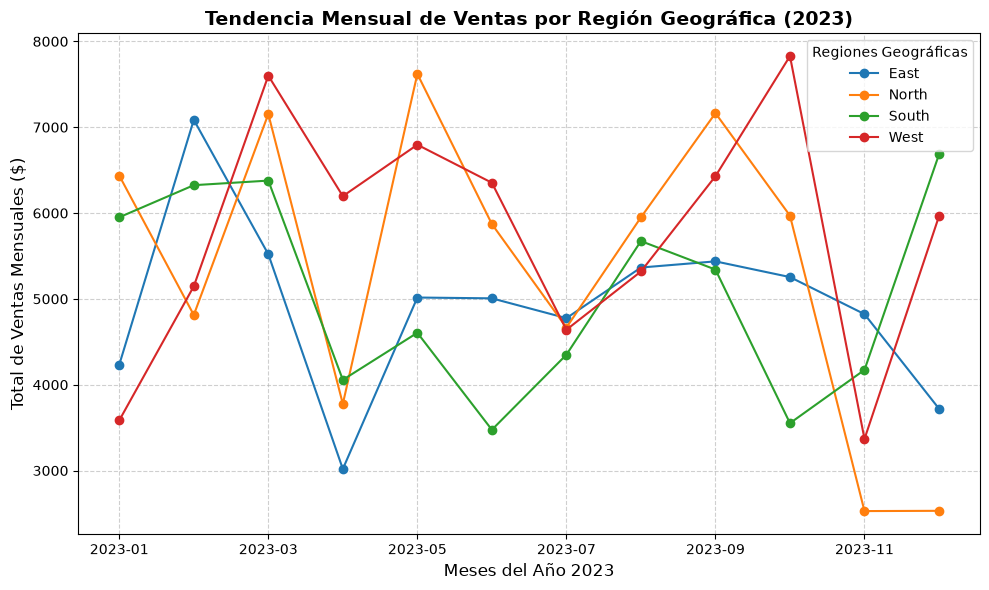

In [31]:
import matplotlib.pyplot as plt

# Crear el gráfico de líneas directamente desde nuestra tabla pivotada
tabla_pivote.plot(kind='line', marker='o', figsize=(10, 6))

# Personalización del gráfico (Títulos y etiquetas)
plt.title('Tendencia Mensual de Ventas por Región Geográfica (2023)', fontsize=14, fontweight='bold')
plt.xlabel('Meses del Año 2023', fontsize=12)
plt.ylabel('Total de Ventas Mensuales ($)', fontsize=12)

# Agregar cuadrícula de fondo para facilitar la lectura visual
plt.grid(True, linestyle='--', alpha=0.6)

# Posicionar la leyenda de las regiones
plt.legend(title='Regiones Geográficas')

# Ajustar márgenes para que no se recorten las etiquetas
plt.tight_layout()

# Mostrar la gráfica en el VS Code Notebook
plt.show()